In [28]:
import numpy as np 
import sympy as sp 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
task_data = pd.read_csv(r'D:\OneDrive\Documents\IIT\STAGE 02\DSGP\Domain AI\ml\TaskPriorityModel\balanced_student_priority_dataset2.csv')

In [30]:
task_data.head(25)

,Student_ID,Year,Semester,Task_Name,Task_Type,Week_Released,Week_Deadline,Current_Week,Weeks_Left,Weight,Difficulty,Estimated_Hours,Current_Workload,Procrastination_Score,Avg_Delay_History,Urgency,RawPriority,PriorityClass
0,1,1,1,CSF Exam,Exam,2,12,8,4,100,7.0,8,6.295377,0.599343,0.372347,0.040762,0.541790,Medium
1,1,1,1,Database Coursework,Coursework,4,12,6,6,100,8.2,12,6.295377,0.599343,0.372347,0.009876,0.658069,High
2,1,1,1,English Coursework,Coursework,3,11,9,2,100,5.0,7,6.295377,0.599343,0.372347,0.242276,0.852169,High
3,1,1,2,Programming Coursework,Coursework,4,11,6,5,60,8.5,12,6.295377,0.599343,0.372347,0.021979,0.487094,Medium
4,1,1,2,Programming Exam,Exam,2,12,12,0,40,6.0,6,6.295377,0.599343,0.372347,1.000000,0.641600,Medium
5,1,1,2,DSA Coursework,Coursework,3,12,10,2,100,8.0,12,6.295377,0.599343,0.372347,0.242276,1.000000,High
6,1,1,2,Computational Mathematics Coursework,Coursework,3,12,7,5,60,7.0,9,6.295377,0.599343,0.372347,0.021979,0.457094,Medium
7,1,1,2,Computational Mathematics Exam,Exam,2,12,5,7,40,7.0,8,6.295377,0.599343,0.372347,0.003698,0.412524,Low
8,1,2,1,OOD Coursework,Coursework,5,12,12,0,100,8.5,12,6.295377,0.599343,0.372347,1.000000,1.000000,High
9,1,2,1,Machine Learning Quiz,Quiz,5,12,12,0,40,6.5,6,6.295377,0.599343,0.372347,0.800000,0.601600,Medium


In [31]:
task_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             11400 non-null  int64  
 1   Year                   11400 non-null  int64  
 2   Semester               11400 non-null  int64  
 3   Task_Name              11400 non-null  object 
 4   Task_Type              11400 non-null  object 
 5   Week_Released          11400 non-null  int64  
 6   Week_Deadline          11400 non-null  int64  
 7   Current_Week           11400 non-null  int64  
 8   Weeks_Left             11400 non-null  int64  
 9   Weight                 11400 non-null  int64  
 10  Difficulty             11400 non-null  float64
 11  Estimated_Hours        11400 non-null  int64  
 12  Current_Workload       11400 non-null  float64
 13  Procrastination_Score  11400 non-null  float64
 14  Avg_Delay_History      11400 non-null  float64
 15  Ur

In [32]:
task_data.describe()

,Student_ID,Year,Semester,Week_Released,Week_Deadline,Current_Week,Weeks_Left,Weight,Difficulty,Estimated_Hours,Current_Workload,Procrastination_Score,Avg_Delay_History,Urgency,RawPriority
count,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,300.500000,1.578947,1.526316,2.842105,11.578947,7.219298,4.359649,68.421053,7.478947,10.421053,4.940041,0.502991,0.402334,0.198921,0.580124
std,173.212437,0.493750,0.499329,1.088898,1.350139,2.993922,2.919294,26.009876,1.067054,3.484188,1.955868,0.199676,0.199821,0.308324,0.206786
min,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,0.000000,30.000000,5.000000,6.000000,1.000000,0.000000,0.000000,0.000196,0.250804
25%,150.750000,1.000000,1.000000,2.000000,12.000000,5.000000,2.000000,40.000000,7.000000,8.000000,3.506605,0.370044,0.258825,0.004437,0.420102
50%,300.500000,2.000000,2.000000,3.000000,12.000000,7.000000,4.000000,60.000000,7.500000,10.000000,4.811394,0.504030,0.397220,0.040762,0.505128
75%,450.250000,2.000000,2.000000,3.000000,12.000000,10.000000,7.000000,100.000000,8.500000,12.000000,6.254658,0.638399,0.546761,0.242276,0.674086
max,600.000000,2.000000,2.000000,5.000000,12.000000,12.000000,11.000000,100.000000,9.500000,22.000000,10.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# Check for missing values
task_data.isnull().sum()

Student_ID               0
Year                     0
Semester                 0
Task_Name                0
Task_Type                0
Week_Released            0
Week_Deadline            0
Current_Week             0
Weeks_Left               0
Weight                   0
Difficulty               0
Estimated_Hours          0
Current_Workload         0
Procrastination_Score    0
Avg_Delay_History        0
Urgency                  0
RawPriority              0
PriorityClass            0
dtype: int64

In [34]:
# Check for duplicate rows
duplicate_rows = task_data.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 0


In [35]:
# Drop unnecessary columns( Student ID, Raw Priority, Task Name)
task_data=task_data.drop(["Student_ID","RawPriority","Task_Name"], axis=1)

In [36]:
task_data.head()

,Year,Semester,Task_Type,Week_Released,Week_Deadline,Current_Week,Weeks_Left,Weight,Difficulty,Estimated_Hours,Current_Workload,Procrastination_Score,Avg_Delay_History,Urgency,PriorityClass
0,1,1,Exam,2,12,8,4,100,7.0,8,6.295377,0.599343,0.372347,0.040762,Medium
1,1,1,Coursework,4,12,6,6,100,8.2,12,6.295377,0.599343,0.372347,0.009876,High
2,1,1,Coursework,3,11,9,2,100,5.0,7,6.295377,0.599343,0.372347,0.242276,High
3,1,2,Coursework,4,11,6,5,60,8.5,12,6.295377,0.599343,0.372347,0.021979,Medium
4,1,2,Exam,2,12,12,0,40,6.0,6,6.295377,0.599343,0.372347,1.000000,Medium


Text(0, 0.5, 'Count')

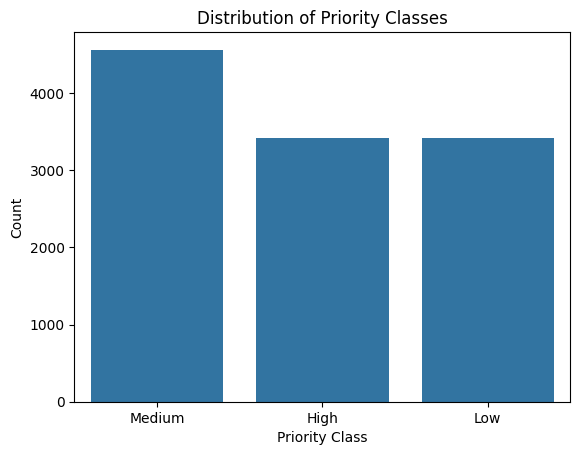

In [37]:
# Target variable distribution
sns.countplot(x='PriorityClass', data=task_data)
plt.title('Distribution of Priority Classes')
plt.xlabel('Priority Class')
plt.ylabel('Count')

In [38]:
# Check for imbalance
counts = task_data['PriorityClass'].value_counts(normalize=True)*100
print(counts)

PriorityClass
Medium    40.0
High      30.0
Low       30.0
Name: proportion, dtype: float64


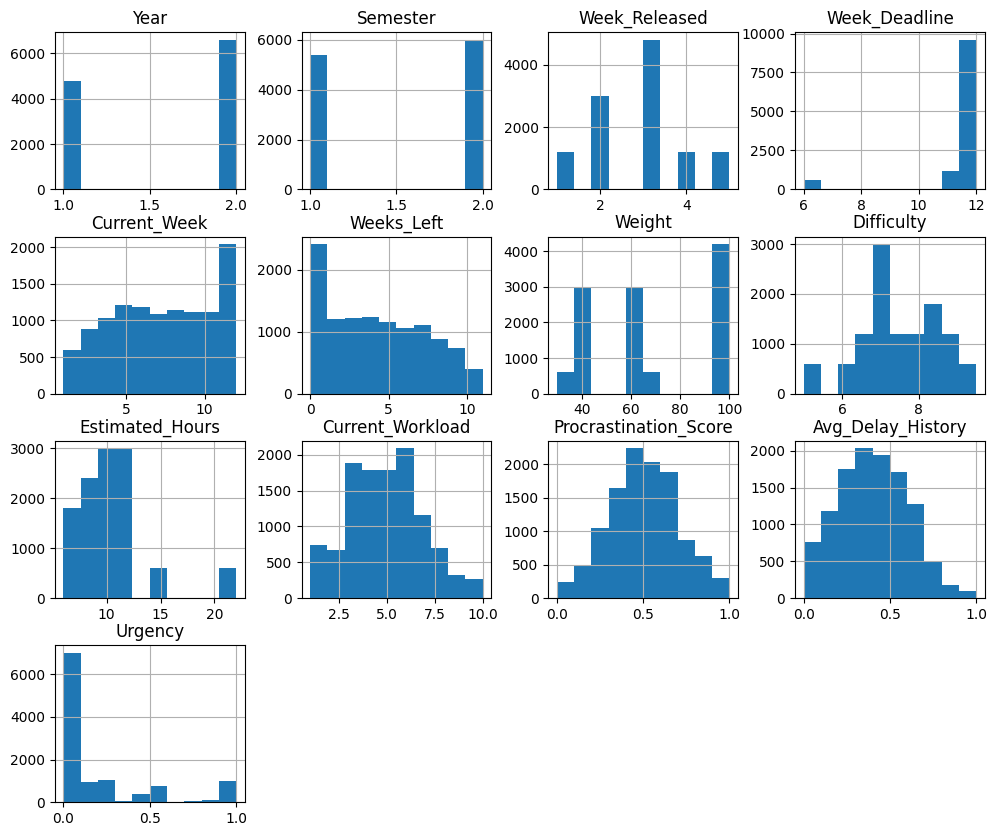

In [39]:
task_data.hist(figsize=(12,10))
plt.show()

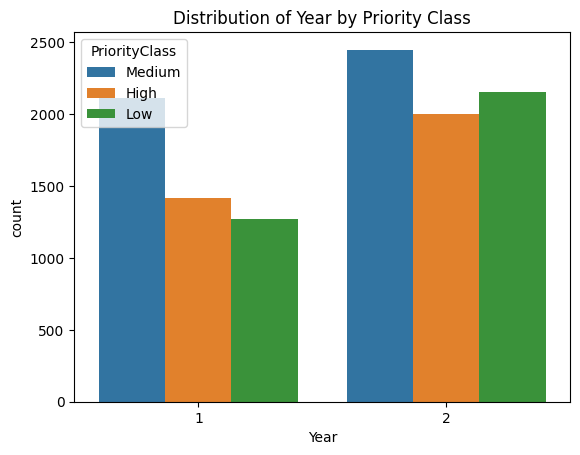

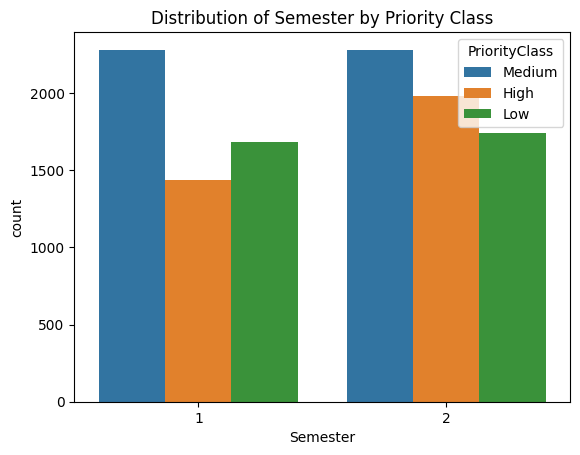

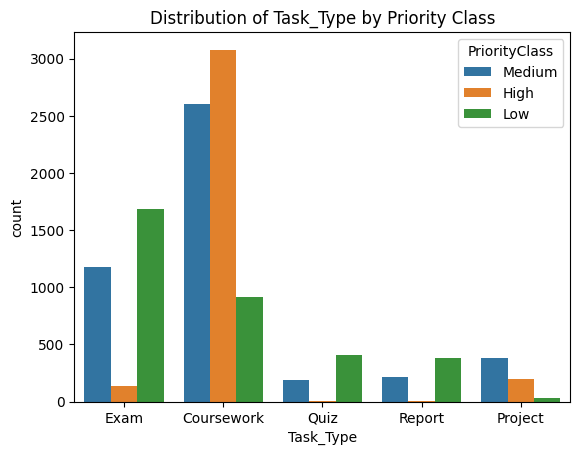

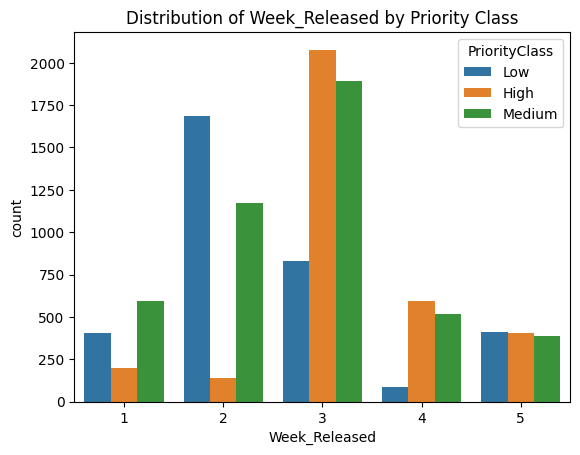

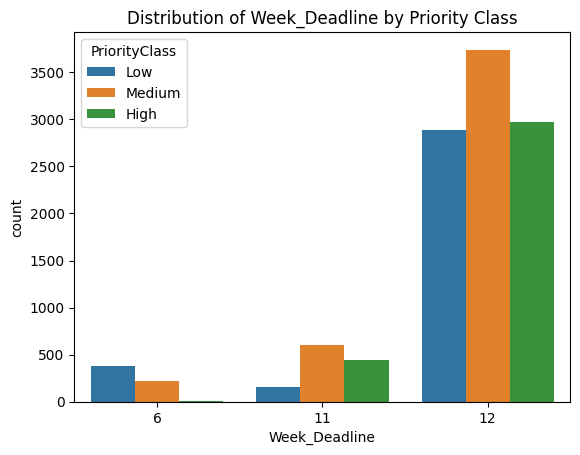

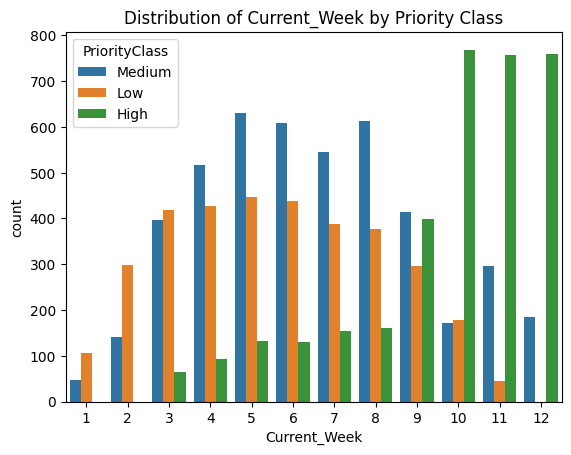

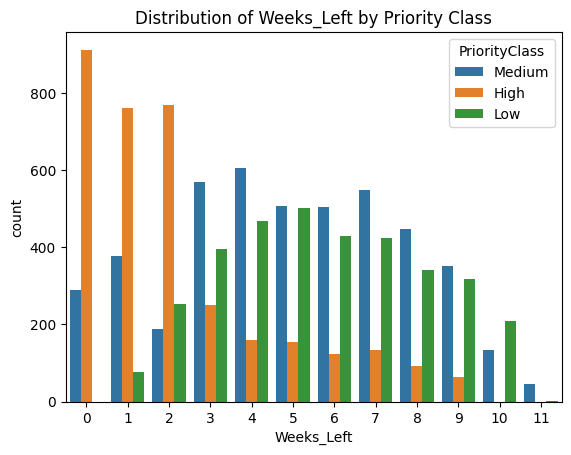

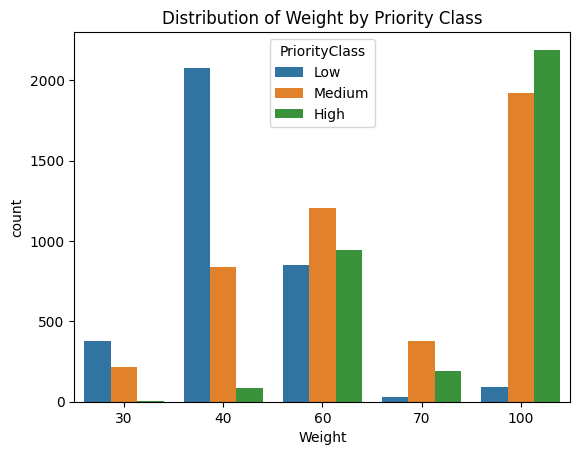

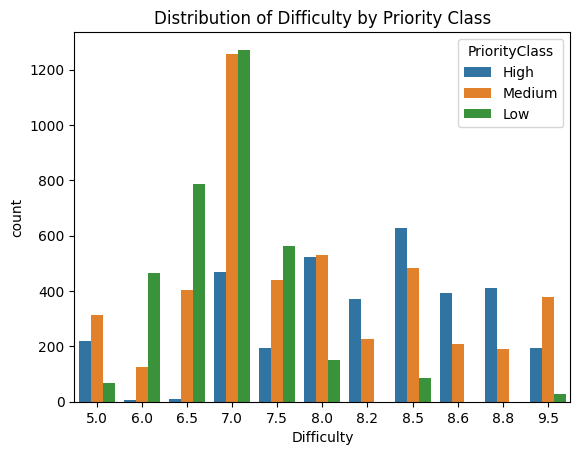

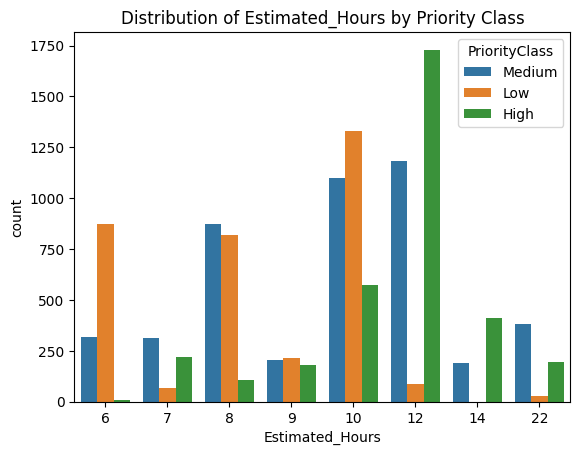

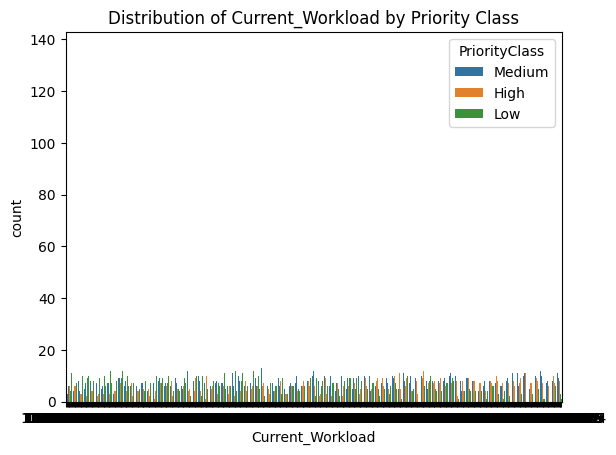

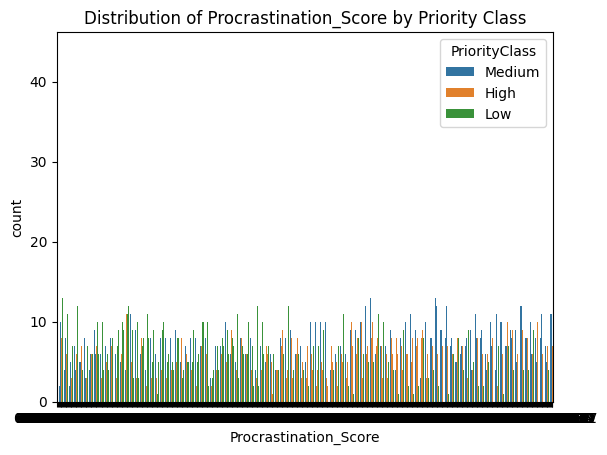

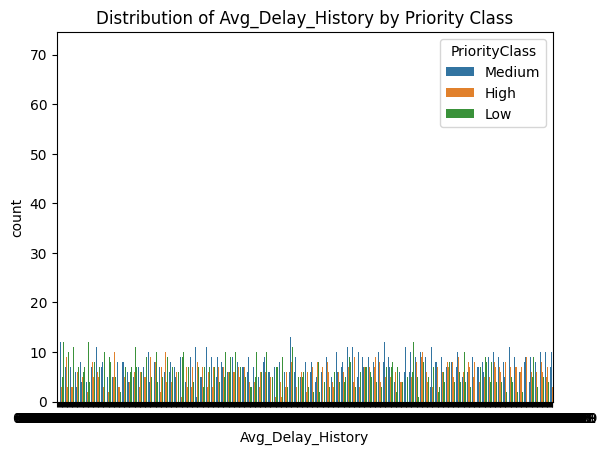

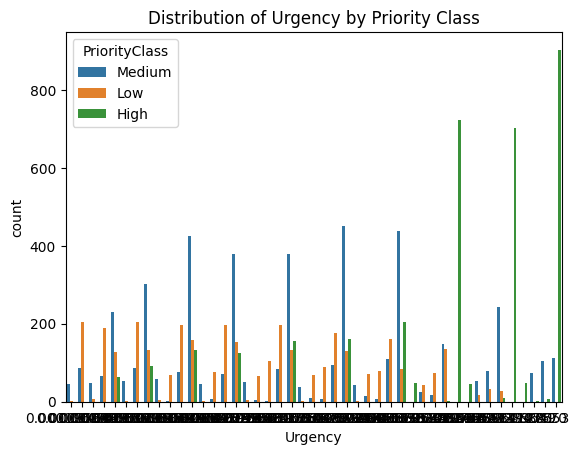

In [40]:
# Univariate Analysis
for i, predictor in enumerate(task_data.columns.drop('PriorityClass')):
    plt.figure(i)
    sns.countplot(x=task_data[predictor], hue=task_data['PriorityClass'])
    plt.title(f'Distribution of {predictor} by Priority Class')
    plt.show()

In [46]:
numeric_df = task_data.select_dtypes(include=["float64", "int64"])

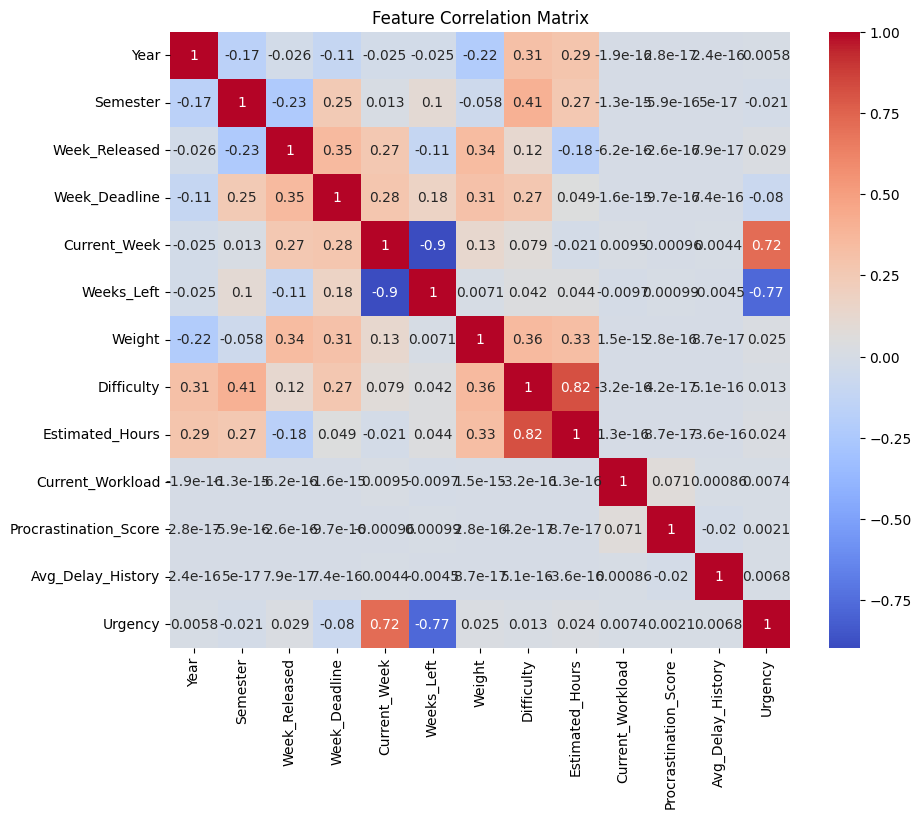

In [47]:
# Correlation Analysis
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

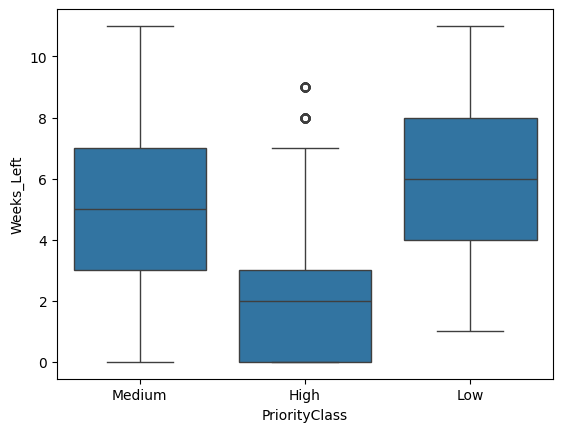

In [48]:
# Boxplot of Weeks_Left by PriorityClass
sns.boxplot(x="PriorityClass", y="Weeks_Left", data=task_data)
plt.show()

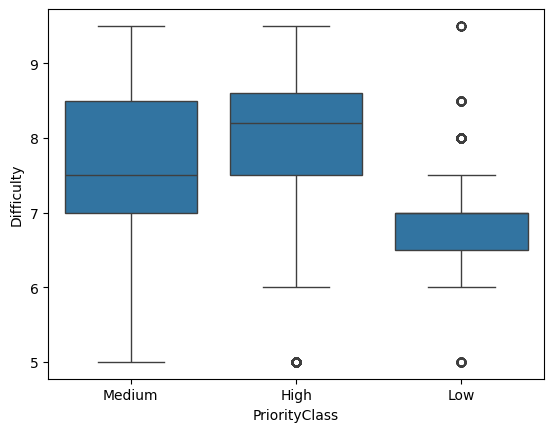

In [49]:
sns.boxplot(x="PriorityClass", y="Difficulty", data=task_data)
plt.show()

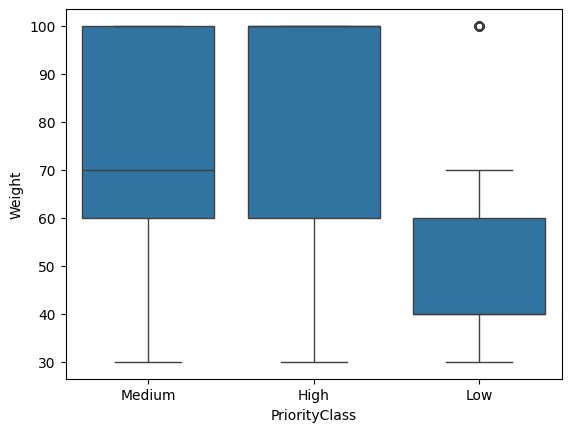

In [50]:
sns.boxplot(x="PriorityClass", y="Weight", data=task_data)
plt.show()

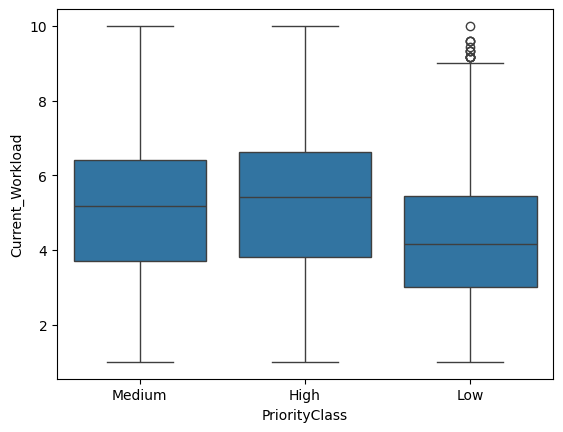

In [52]:
sns.boxplot(x="PriorityClass", y="Current_Workload", data=task_data)
plt.show()

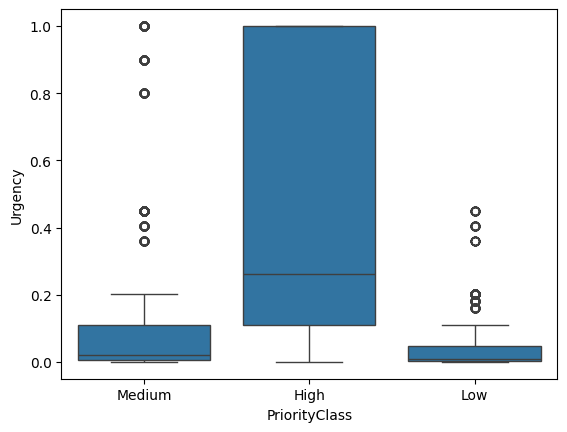

In [53]:
sns.boxplot(x="PriorityClass", y="Urgency", data=task_data)
plt.show()

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
task_data["PriorityClass"] = le.fit_transform(task_data["PriorityClass"])

In [55]:
# Encoding 
task_data = pd.get_dummies(task_data, columns=["Task_Type"], drop_first=True)

In [56]:
task_data.to_csv(r'D:\OneDrive\Documents\IIT\STAGE 02\DSGP\Domain AI\ml\TaskPriorityModel\processed_task_data.csv', index=False)